In [2]:
# %%
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "visitor_features_engineered.parquet"

df = pd.read_parquet(DATA_PATH)

df.shape

(535391, 15)

In [2]:
df.head()

,visitor_key,browser,os_name,region,has_signup,test_engagement_state,tests_taken_count_bucket,tests_completed_count_bucket,test_latency_bucket,first_test_taken,first_completed_test_taken,os_name_clean,first_test_domain,first_completed_test_domain,sub_region
0,a03e6e1f880e7c684fccb71b9451a7e8,mobile_web,iOS,Alabama,0,No Test,0,0,No Test,None,None,iOS,No Test,No Completed Test,East South Central
1,95a936cbca6336e2df0f577f00056698,mobile_web,iOS,Alabama,0,No Test,0,0,No Test,None,None,iOS,No Test,No Completed Test,East South Central
2,ffebac852989f1b0b93050f222ec99bb,mobile_web,iOS,Alabama,0,Test Started Only,1,0,Immediate,Dissociative Identity Disorder,None,iOS,Trauma & Dissociation,No Completed Test,East South Central
3,fad773f668095988f35fbfffa32d4f03,mobile_web,iOS,Alabama,0,Test Started Only,1,0,Immediate,Gender Dysphoria,None,iOS,Sexual & Gender Health,No Completed Test,East South Central
4,d2c9956f0079bd53370c5b14075bae61,mobile_web,Android,Alabama,0,Test Started Only,1,0,Immediate,Social Anxiety Disorder,None,Android,Anxiety & Stress,No Completed Test,East South Central


In [3]:
# %%
flow = (
    df.assign(
        signup_outcome=np.where(df["has_signup"], "Signup", "No Signup")
    )
    .groupby(["test_engagement_state", "signup_outcome"], dropna=False)
    .size()
    .reset_index(name="count")
)

flow.sort_values("count", ascending=False).head(10)

,test_engagement_state,signup_outcome,count
2,Test Completed,No Signup,416545
4,Test Started Only,No Signup,77511
0,No Test,No Signup,32608
3,Test Completed,Signup,8640
1,No Test,Signup,48
5,Test Started Only,Signup,39


In [4]:
import sys
sys.executable

'/Users/davidreynolds/projects/online_teletherapy_signups/.venv/bin/python'

In [8]:
%pip install -U nbformat

Note: you may need to restart the kernel to use updated packages.


In [5]:
# %%
import plotly.graph_objects as go

left_nodes = ["No Test", "Test Started Only", "Test Completed"]
right_nodes = ["No Signup", "Signup"]

# Ensure ordering and handle unexpected categories safely
flow["test_engagement_state"] = flow["test_engagement_state"].astype(str)
flow["signup_outcome"] = flow["signup_outcome"].astype(str)

# Build node list
nodes = left_nodes + right_nodes

node_index = {name: i for i, name in enumerate(nodes)}

# Filter to expected nodes only (optional but keeps chart clean)
flow_filtered = flow[
    flow["test_engagement_state"].isin(left_nodes)
    & flow["signup_outcome"].isin(right_nodes)
].copy()

sources = flow_filtered["test_engagement_state"].map(node_index)
targets = flow_filtered["signup_outcome"].map(node_index)
values = flow_filtered["count"].tolist()

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=nodes,
                pad=18,
                thickness=18,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
            ),
        )
    ]
)

fig.update_layout(
    title_text="Customer Journey: Test Engagement → Signup Outcome",
    font_size=12,
)

fig.show()


In [6]:
# %%
total_visitors = len(df)
has_test = df["test_engagement_state"].isin(["Test Started Only", "Test Completed"]).sum()
completed_test = (df["test_engagement_state"] == "Test Completed").sum()
signups = df["has_signup"].sum()

funnel = pd.DataFrame({
    "stage": ["Visitors", "Took a Test", "Completed a Test", "Signup"],
    "count": [total_visitors, has_test, completed_test, signups],
})

funnel["pct_of_visitors"] = funnel["count"] / total_visitors
funnel

,stage,count,pct_of_visitors
0,Visitors,535391,1.000000
1,Took a Test,502735,0.939005
2,Completed a Test,425185,0.794158
3,Signup,8727,0.016300


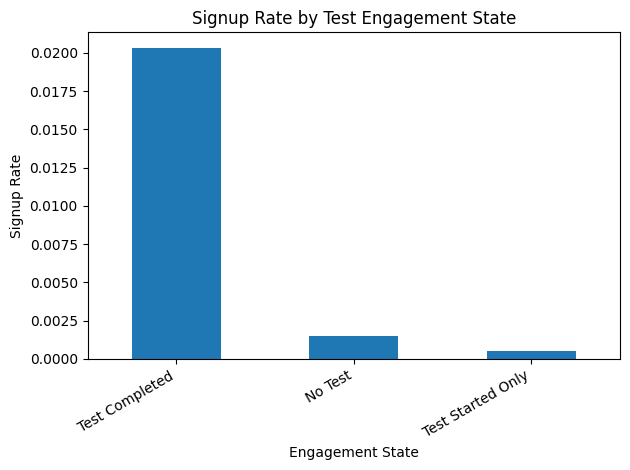

In [7]:
# %%
import matplotlib.pyplot as plt

rates = (
    df.groupby("test_engagement_state")["has_signup"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
rates.plot(kind="bar")
plt.title("Signup Rate by Test Engagement State")
plt.ylabel("Signup Rate")
plt.xlabel("Engagement State")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# %%
if "first_test_domain" in df.columns:
    df_test_takers = df[df["first_test_domain"] != "No Test"].copy()
    df_test_takers["signup_outcome"] = np.where(df_test_takers["has_signup"], "Signup", "No Signup")

    flow2 = (
        df_test_takers.groupby(["first_test_domain", "signup_outcome"])
        .size()
        .reset_index(name="count")
    )

    left_nodes2 = sorted(df_test_takers["first_test_domain"].unique().tolist())
    right_nodes2 = ["No Signup", "Signup"]
    nodes2 = left_nodes2 + right_nodes2
    idx2 = {n: i for i, n in enumerate(nodes2)}

    sources2 = flow2["first_test_domain"].map(idx2)
    targets2 = flow2["signup_outcome"].map(idx2)
    values2 = flow2["count"].tolist()

    fig2 = go.Figure(
        data=[go.Sankey(
            node=dict(label=nodes2, pad=18, thickness=18),
            link=dict(source=sources2, target=targets2, value=values2)
        )]
    )
    fig2.update_layout(
        title_text="Customer Journey: First Test Domain → Signup Outcome (Test Takers)",
        font_size=11
    )
    fig2.show()